In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# This tells Python to go up one directory (..) and then into data
file_path = '../data/entry_data.csv'

# Let's verify if the file exists before reading
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Success! Data loaded.")
    print(df.head())
else:
    print(f"Still can't find it. My current location is: {os.getcwd()}")
    print("Check if the filename has any extra spaces or '.csv' written twice.")

Success! Data loaded.
   Visitor_ID              Name  Visit_Date  Nationality  \
0           1      James Harris  1995-01-22       France   
1           2     David Bernard  1995-01-17          USA   
2           3      Hans Jackson  1995-01-08        Italy   
3           4      Sarah Harris  1995-01-11  Netherlands   
4           5  Isabella Jackson  1995-01-04  Netherlands   

         Purpose_of_Visit  Age  Gender  Expedition_Duration_Days  \
0  Everest Base Camp Trek   65    Male                        11   
1    Everest Summit Climb   31    Male                        52   
2  Everest Base Camp Trek   52    Male                        16   
3  Photography Expedition   28  Female                        16   
4  Everest Base Camp Trek   23  Female                        16   

   Permit_Fee_USD  Year  Month  
0            1500  1995      1  
1           11000  1995      1  
2            1500  1995      1  
3            1000  1995      1  
4            1500  1995      1  


In [3]:
print(df.columns)
print(df.info())

Index(['Visitor_ID', 'Name', 'Visit_Date', 'Nationality', 'Purpose_of_Visit',
       'Age', 'Gender', 'Expedition_Duration_Days', 'Permit_Fee_USD', 'Year',
       'Month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169024 entries, 0 to 169023
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Visitor_ID                169024 non-null  int64 
 1   Name                      169024 non-null  object
 2   Visit_Date                169024 non-null  object
 3   Nationality               169024 non-null  object
 4   Purpose_of_Visit          169024 non-null  object
 5   Age                       169024 non-null  int64 
 6   Gender                    169024 non-null  object
 7   Expedition_Duration_Days  169024 non-null  int64 
 8   Permit_Fee_USD            169024 non-null  int64 
 9   Year                      169024 non-null  int64 
 10  Month                     169

In [4]:
df.head(10)

,Visitor_ID,Name,Visit_Date,Nationality,Purpose_of_Visit,Age,Gender,Expedition_Duration_Days,Permit_Fee_USD,Year,Month
0,1,James Harris,1995-01-22,France,Everest Base Camp Trek,65,Male,11,1500,1995,1
1,2,David Bernard,1995-01-17,USA,Everest Summit Climb,31,Male,52,11000,1995,1
2,3,Hans Jackson,1995-01-08,Italy,Everest Base Camp Trek,52,Male,16,1500,1995,1
3,4,Sarah Harris,1995-01-11,Netherlands,Photography Expedition,28,Female,16,1000,1995,1
4,5,Isabella Jackson,1995-01-04,Netherlands,Everest Base Camp Trek,23,Female,16,1500,1995,1
5,6,Mei Suzuki,1995-01-18,Australia,Gokyo Lakes Trek,64,Female,17,1200,1995,1
6,7,Arjun Brown,1995-01-19,Canada,Everest Base Camp Trek,58,Male,15,1500,1995,1
7,8,Noah Johnson,1995-01-28,Spain,Everest Base Camp Trek,36,Male,11,1500,1995,1
8,9,Oliver Dubois,1995-01-12,Australia,Everest Base Camp Trek,41,Male,12,1500,1995,1
9,10,Charlotte Harris,1995-01-20,Italy,Photography Expedition,59,Female,11,1000,1995,1


In [5]:
# 1. Group by Year and Month to get the count of visitors
monthly_data = df.groupby(['Year', 'Month']).size().reset_index(name='Total_Visitors')

# 2. Create a proper 'Date' column for plotting
# We'll assume the 1st of the month for the timeline
monthly_data['Date'] = pd.to_datetime(monthly_data['Year'].astype(str) + '-' + monthly_data['Month'].astype(str) + '-01')

# 3. Sort by date
monthly_data = monthly_data.sort_values('Date')

print(monthly_data.tail(20))

     Year  Month  Total_Visitors       Date
352  2024      5            2009 2024-05-01
353  2024      6            1004 2024-06-01
354  2024      7            1004 2024-07-01
355  2024      8            1004 2024-08-01
356  2024      9            1004 2024-09-01
357  2024     10            2009 2024-10-01
358  2024     11            2009 2024-11-01
359  2024     12            1004 2024-12-01
360  2025      1            1015 2025-01-01
361  2025      2            1015 2025-02-01
362  2025      3            1015 2025-03-01
363  2025      4            2030 2025-04-01
364  2025      5            2030 2025-05-01
365  2025      6            1015 2025-06-01
366  2025      7            1015 2025-07-01
367  2025      8            1015 2025-08-01
368  2025      9            1015 2025-09-01
369  2025     10            2030 2025-10-01
370  2025     11            2030 2025-11-01
371  2025     12            1015 2025-12-01


In [6]:
# Create Lag Features
monthly_data['Lag_1'] = monthly_data['Total_Visitors'].shift(1)  # Previous month
monthly_data['Lag_12'] = monthly_data['Total_Visitors'].shift(12) # Same month last year

# Drop the NaN rows created by shifting
monthly_data.dropna(inplace=True)

## The visualizing the "M-Shape"        
This graph verifies that Nepal tourism has two peak seasons.

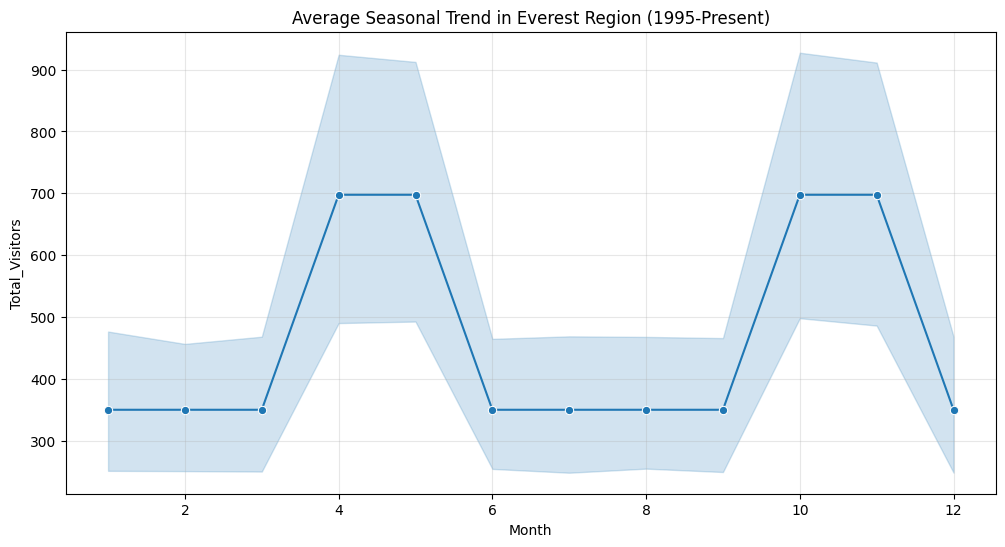

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_data, x='Month', y='Total_Visitors', marker='o')
plt.title('Average Seasonal Trend in Everest Region (1995-Present)')
plt.grid(True, alpha=0.3)
plt.show()

## The Prediction Model(Random Forest)

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Features: Year, Month, Lag_1, Lag_12
X = monthly_data[['Year', 'Month', 'Lag_1', 'Lag_12']]
y = monthly_data['Total_Visitors']

# Split data: Use the older data to train, and the most recent year to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)
print(f"Model Error: {mean_absolute_error(y_test, predictions)} visitors")

Model Error: 485.875 visitors


## Prediction vs Actual Plot
### We calculate the MAE(Most Absolute Error) or RMSE.

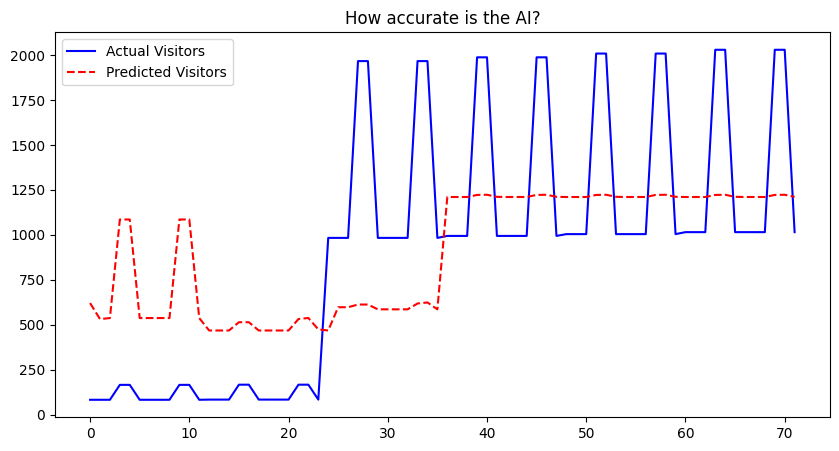

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Visitors', color='blue')
plt.plot(predictions, label='Predicted Visitors', color='red', linestyle='--')
plt.legend()
plt.title('How accurate is the AI?')
plt.show()

## Factors that matters most

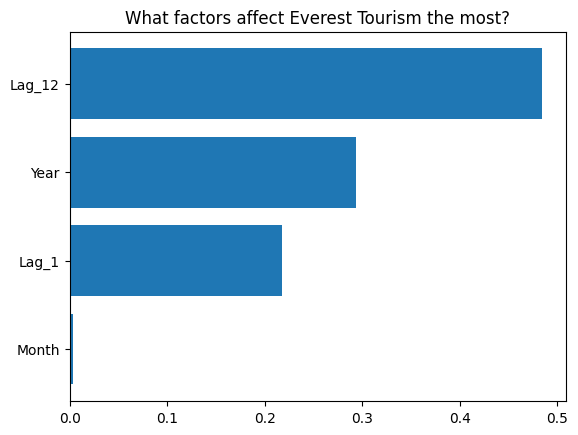

In [10]:
import numpy as np
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.title('What factors affect Everest Tourism the most?')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.show()